## <span style="color:blue"> Lezione 9 </span>



In [1]:

import matplotlib.pyplot as plt


import numpy as np

parent_folder="l_09_all_es/"

### <span style="color:DodgerBlue"> Esercizio 9.1 </span>



Il problema del commesso viaggiatore è il seguente: sono date un numero $R$ città disposte su una mappa (ossia punti nel piano cartesiano) e si vuole trovare il miglior (più breve percorso) che partendo da una città fissata visiti tutte le altre una e una sola volta, per ritornare alla fine al punto di partenza. 

Lo si è affrontato tramite un algoritmo genetico. Si è creata una popolazione di $N$ percorsi circolari contenenti la sequenza di indici in cui visitare le città (cromosoma). Il primo e ultimo indice sono stati fissati a zero, rappresentando la partenza da una città fissata e il ritorno ad essa. (Ad esempio, per $R=5$ città, un percorso potrebbe essere $p=[0,1,2,3,4,5,0]$). 

Ad ogni step dell'algoritmo viene creata una nuova generazione con le seguenti regole: 
1. Si ordina la popolazione per lunghezza del percorso
2. Si selezionano due genitori con la regola $j=N r^p$, con $j$ indice dell'individuo,$N$ numero di individui, 
3. Con probabilità $P_x$ si effettua il crossover tra i genitori
4. Con probabilità $P_m$ si muta il genitore 1, sempre con probabilità $P_m$ si muta il genitore 2 
5. I percorsi risultanti vengono aggiunti alla nuova generazione. 
6. Si ripete dal punto 2. al punto 5. finchè la nuova generazione non ha $N$ individui. A quel punto si riparte dal punto 1. 


Il crossover consiste nel scegliere randomicamente un punto di taglio (escludendo il primo e l'ultimo indice) e tagliare ad esso entrambi i genitori, eliminando la parte a destra del taglio. Ciascuno dei due viene poi completato con gli indici mancanti presi nell'ordine in cui compaiono nell'altro genitore. 

Le mutazioni sono di tre tipi, che vengono scelti randomicamente con probabilità uniforme. Esse agiscono solo sul corpo interno del cromosoma, ossia escludendo il primo e ultimo indice, fissati a zero. 
1. _Swap_ : si selezionano randomicamente con probabilità uniforme due indici interni del cromosoma, e si scambiano i valori contenuti in essi
2. _Shift_ : si seleziona randomicamente con probabilità uniforme una quantità $m =1,...,R-1$ e si "shiftano" gli indici interni del cromosoma di quella quantità 
3. _Reverse_: si selezionano randomicamente con probabilità uniforme due indici interni del cromosoma e si inverte l'ordine della sequenza tra essi



L'algoritmo, con parametri $P_x=0.7, P_m=0.5, p=2$ è stato testato prima su $R=34$ città disposte randomicamente (probabilità uniforme) su di una circonferenza, problema per cui la soluzione ottimale è evidente. Successivamente, lo si è utilizzato per cercare il miglior percorso in grado di unire $R=34$ città disposte randomicamente (probabilità uniforme) dentro un quadrato.

### Città sulla circonferenza



Il raggio della circonferenza è stato preso $r=1$ e sono state utilizzate $M=1000$ generazioni di $N=200$ individui ciascuna. 

La cella sottostante carica i dati: le posizioni delle città, la lunghezza del miglior percorso di ogni generazione e il percorso stesso.

In [2]:
C_cities=np.loadtxt(f"{parent_folder}cities_on_circle.csv")



cols=range(3,3 + len(C_cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1

#carica la lunghezza media della metà migliore della popolazione per ogni generazione e la lunghezza del miglior percorso 
C_avg_len,C_best_len=np.loadtxt(f"{parent_folder}circle_paths.csv",usecols=(1,2),unpack=True,skiprows=1)

C_best_path=np.loadtxt(f"{parent_folder}circle_paths.csv",usecols=cols,skiprows=len(C_best_len))#carica solo l'ultimo percorso (il migliore di tutti)


C_gen=np.arange(1,len(C_best_len)+1)


La cella sottostante grafica l'andamento della lunghezza del miglior percorso di ogni generazione in funzione delle stesse (a sinistra) e il miglior percorso dell'ultima generazione (a destra).

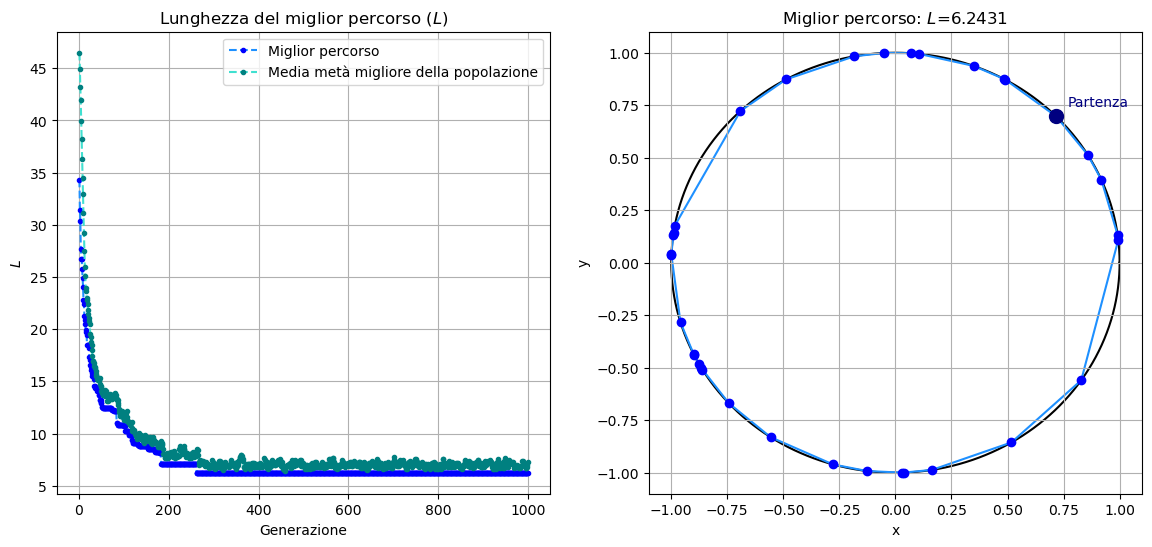

In [3]:
R=1#Raggio della circonferenza


fig,axs=plt.subplots(1,2,figsize=[14,6])


axs[0].plot(C_gen,C_best_len,"--.",mfc="blue",mec="blue",color="dodgerblue",label="Miglior percorso")
axs[0].plot(C_gen,C_avg_len,"--.",mfc="teal",mec="teal",color="turquoise",label="Media metà migliore della popolazione")

axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()


theta=np.linspace(0,2*np.pi,1000)
axs[1].plot(R*np.cos(theta),R*np.sin(theta),color="black",zorder=0)#circonferenza, per confronto

axs[1].scatter(C_cities[:,0],C_cities[:,1],color="blue",zorder=2)#città 

axs[1].scatter(C_cities[0,0],C_cities[0,1],color="navy",s=100,zorder=2)#città di partenza

axs[1].text(C_cities[0,0] + 0.05, C_cities[0,1] + 0.05, "Partenza", fontsize=10, ha='left',color="navy")#segna la città di partenza

index=C_best_path.astype(int)#ordine in cui le città vengono visitate (percorso)
axs[1].plot(C_cities[index,0],C_cities[index,1],color="dodgerblue",zorder=1) #unisce le città nell'ordine in cui vengono visitate


axs[1].grid()
axs[1].set_title(fr"Miglior percorso: $L$={C_best_len[-1]:.4f}")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y");



E' evidente che il percorso ottenuto è il più corto possibile.

### Città nel quadrato


Il lato del quadrato è stato preso $L=1$ e sono state utilizzate $M=1000$ generazioni di $N=500$ individui ciascuna.

La cella sottostante carica i dati: le posizioni delle città, la lunghezza del miglior percorso di ogni generazione e il percorso stesso.

In [4]:
SQ_cities=np.loadtxt(f"{parent_folder}cities_in_square.csv")



cols=range(3,3 + len(SQ_cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1

#carica la lunghezza media della metà migliore della popolazione per ogni generazione e la lunghezza del miglior percorso 
SQ_avg_len,SQ_best_len=np.loadtxt(f"{parent_folder}square_paths.csv",usecols=(1,2),unpack=True,skiprows=1)

SQ_best_path=np.loadtxt(f"{parent_folder}square_paths.csv",usecols=cols,skiprows=len(SQ_best_len))#carica solo l'ultimo percorso (il migliore di tutti)


SQ_gen=np.arange(1,len(SQ_best_len)+1)


La cella sottostante grafica l'andamento della lunghezza del miglior percorso di ogni generazione in funzione delle stesse (a sinistra) e il miglior percorso dell'ultima generazione (a destra).

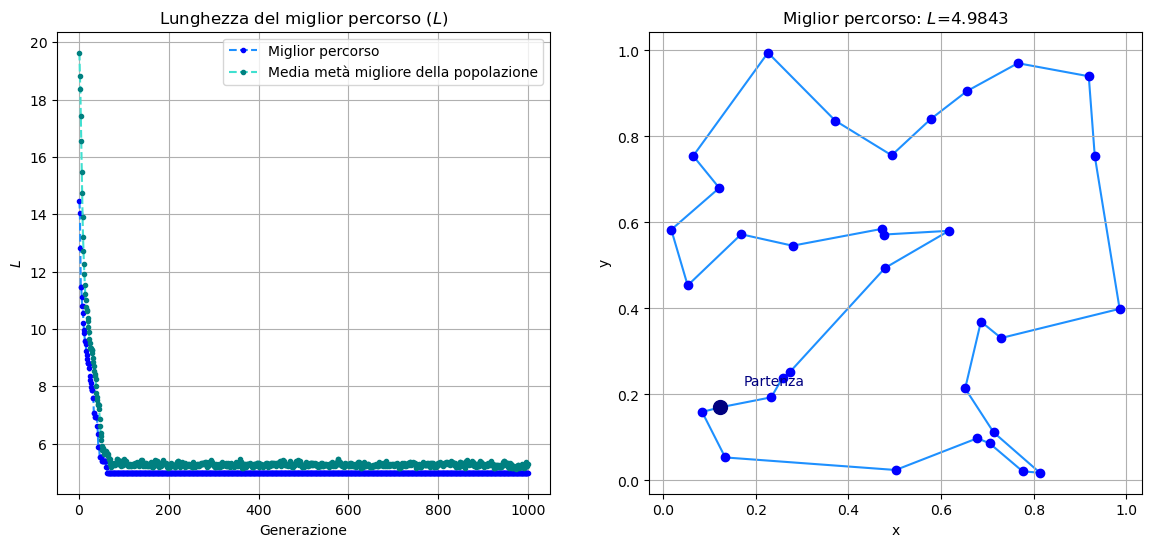

In [5]:


fig,axs=plt.subplots(1,2,figsize=[14,6])


axs[0].plot(SQ_gen,SQ_best_len,"--.",mfc="blue",mec="blue",color="dodgerblue",label="Miglior percorso")
axs[0].plot(SQ_gen,SQ_avg_len,"--.",mfc="teal",mec="teal",color="turquoise",label="Media metà migliore della popolazione")

axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()

axs[1].scatter(SQ_cities[:,0],SQ_cities[:,1],color="blue",zorder=2)#città 

axs[1].scatter(SQ_cities[0,0],SQ_cities[0,1],color="navy",s=100,zorder=2)#città di partenza

axs[1].text(SQ_cities[0,0] + 0.05, SQ_cities[0,1] + 0.05, "Partenza", fontsize=10, ha='left',color="navy")#segna la città di partenza

index=SQ_best_path.astype(int)#ordine in cui le città vengono visitate (percorso)
axs[1].plot(SQ_cities[index,0],SQ_cities[index,1],color="dodgerblue",zorder=1) #unisce le città nell'ordine in cui vengono visitate


axs[1].grid()
axs[1].set_title(fr"Miglior percorso: $L$={SQ_best_len[-1]:.4f}")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y");



Per meglio apprezzare il funzionamento dell'algoritmo sono state realizzate due gif che mostrano l'evoluzione del miglior percorso (della generazione) con la sua lunghezza in funzione della generazione. 

![Alt Text](circonferenza.gif) 
![Alt Text](quadrato.gif) 


Di seguito sono riportati i codici utilizzati per generarle. 

In [6]:
import matplotlib.animation as animation 

### Circonferenza

In [7]:
%%capture

C_paths=np.loadtxt(f"{parent_folder}circle_paths.csv",usecols=cols,skiprows=1)

fig,ax=plt.subplots(1,1,figsize=[6,6])

theta=np.linspace(0,2*np.pi,1000)
ax.plot(R*np.cos(theta),R*np.sin(theta),color="black",zorder=0)#circonferenza, per confronto
ax.scatter(C_cities[:,0],C_cities[:,1],color="blue",zorder=2)#città
ax.scatter(C_cities[0,0],C_cities[0,1],color="navy",s=100,zorder=2)#città di partenza
ax.text(C_cities[0,0] + 0.05, C_cities[0,1] + 0.05, "Partenza", fontsize=10, ha='left',color="navy")#segna la città di partenza

index=C_paths[0].astype(int)#ordine in cui le città vengono visitate (percorso)
path=ax.plot(C_cities[index,0],C_cities[index,1],color="dodgerblue",zorder=1)[0]#unisce le città nell'ordine in cui vengono visitate
ax.set_title(fr"Generazione: 1  | Lunghezza miglior percorso $L$={C_best_len[0]:.4f}")

ax.grid()
ax.set_xlabel("x")
ax.set_ylabel("y")


def update(frame):#funzione di aggiornamento (per funcanimation)
    index=C_paths[frame].astype(int)#ordine in cui le città vengono visitate (percorso)
    path.set_xdata(C_cities[index,0])
    path.set_ydata(C_cities[index,1])
    ax.set_title(fr"Generazione: {frame}  | Lunghezza miglior percorso $L$={C_best_len[frame]:.4f}")

    return path



anim = animation.FuncAnimation(fig=fig, func=update, frames=400, interval=30) 
#anim.save("circonferenza.gif") # (commentato per evitare di sovrascrivere il file)

### Quadrato

In [8]:
%%capture

SQ_paths=np.loadtxt(f"{parent_folder}square_paths.csv",usecols=cols,skiprows=1)

fig,ax=plt.subplots(1,1,figsize=[6,6])

ax.scatter(SQ_cities[:,0],SQ_cities[:,1],color="blue",zorder=2)#città
ax.scatter(SQ_cities[0,0],SQ_cities[0,1],color="navy",s=100,zorder=2)#città di partenza
ax.text(SQ_cities[0,0] + 0.05, SQ_cities[0,1] + 0.03, "Partenza", fontsize=10, ha='right',color="navy")#segna la città di partenza

index=SQ_paths[0].astype(int)#ordine in cui le città vengono visitate (percorso)
path=ax.plot(SQ_cities[index,0],SQ_cities[index,1],color="dodgerblue",zorder=1)[0]#unisce le città nell'ordine in cui vengono visitate
ax.set_title(fr"Generazione: 1  | Lunghezza miglior percorso $L$={SQ_best_len[0]:.4f}")

ax.grid()
ax.set_xlabel("x")
ax.set_ylabel("y")


def update(frame):#funzione di aggiornamento (per funcanimation)
    index=SQ_paths[frame].astype(int)#ordine in cui le città vengono visitate (percorso)
    path.set_xdata(SQ_cities[index,0])
    path.set_ydata(SQ_cities[index,1])
    ax.set_title(fr"Generazione: {frame}  | Lunghezza miglior percorso $L$={SQ_best_len[frame]:.4f}")

    return path



anim = animation.FuncAnimation(fig=fig, func=update, frames=200, interval=40) 
#anim.save("quadrato.gif") # (commentato per evitare di sovrascrivere il file)